<a href="https://colab.research.google.com/github/CassioLima09/NLP_with_Transformers/blob/main/07_question_answering_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Uncomment and run this cell if you're on Colab or Kaggle
!git clone https://github.com/nlp-with-transformers/notebooks.git
%cd notebooks
from install import *
install_requirements(is_chapter7_v2=True)

In [ ]:
!pip install transformers datasets accelerate evaluate matplotlib pandas

In [ ]:
from utils import *
setup_chapter()

In [ ]:
%env TOKENIZERS_PARALLELISM=false
# define uma variavel de ambiente
# os tokenizadores serao processados de forma nao paralela e isso evita conflitos


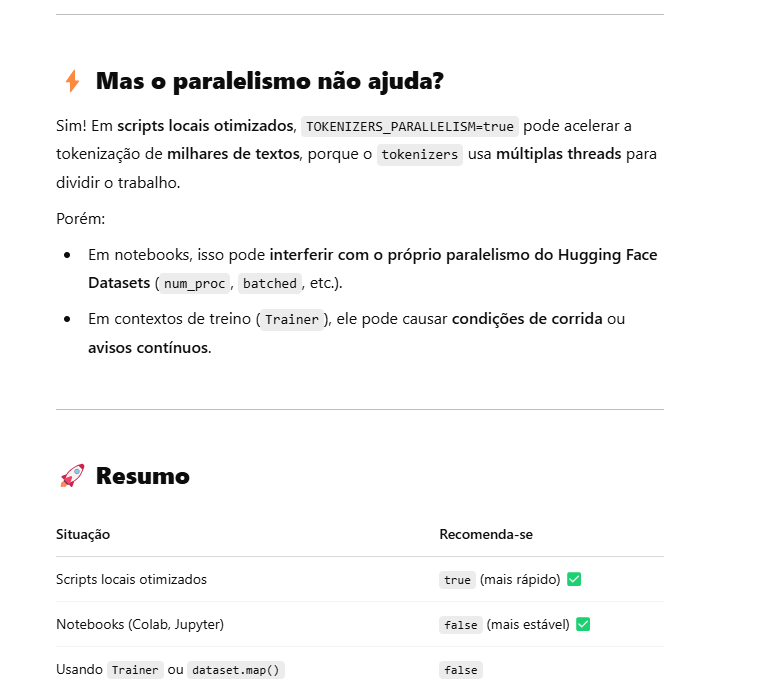

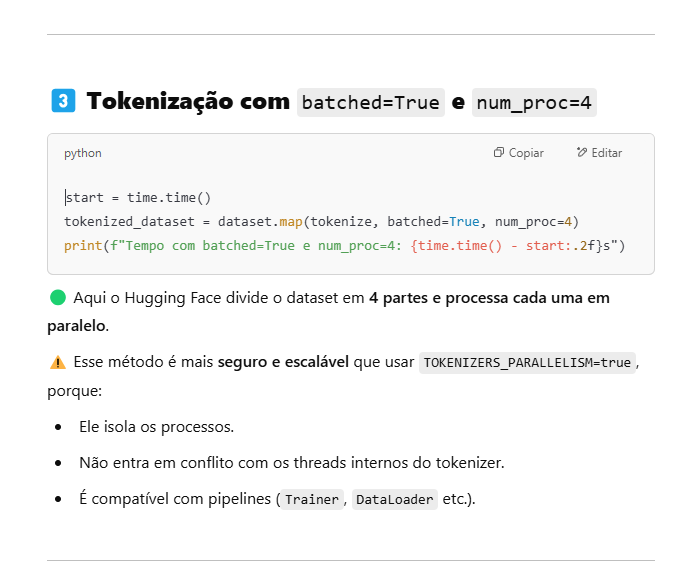

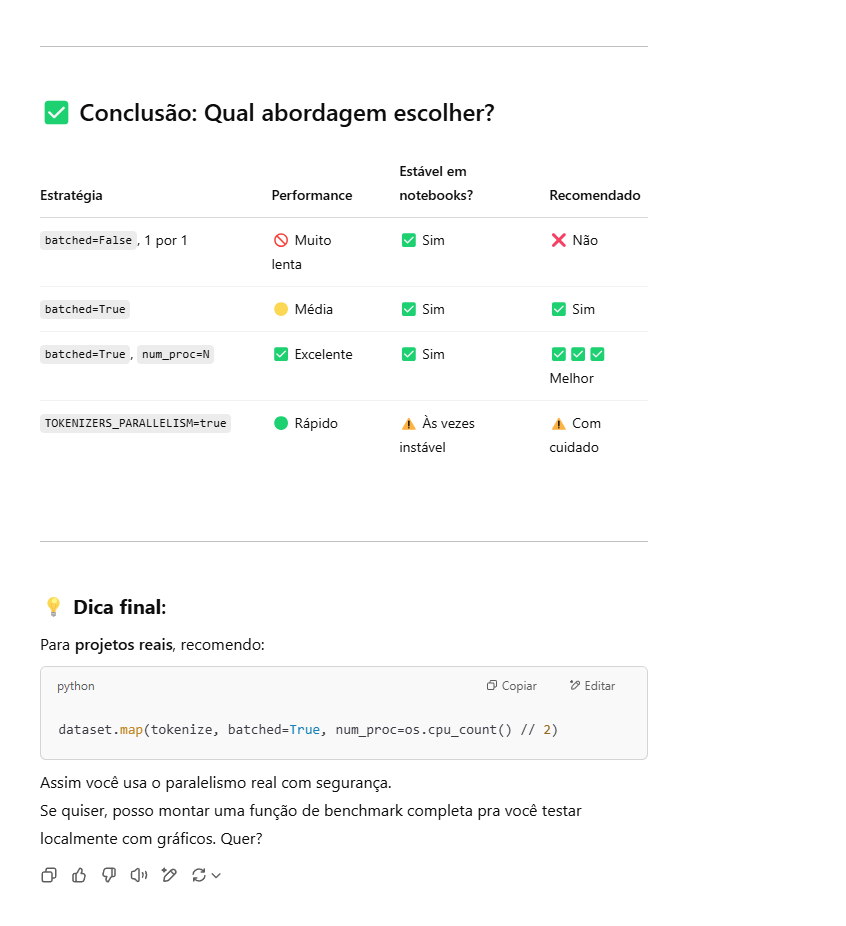

In [ ]:
# Suppress Haystack logging
import logging
for module in ["farm.utils", "farm.infer", "haystack.reader.farm.FARMReader",
              "farm.modeling.prediction_head", "elasticsearch", "haystack.eval",
               "haystack.document_store.base", "haystack.retriever.base",
              "farm.data_handler.dataset"]:
    module_logger = logging.getLogger(module)
    module_logger.setLevel(logging.ERROR)

    #O módulo logging do Python é usado para exibir mensagens de depuração, erros,
   #  avisos e outros tipos de eventos durante a execução do código.
   # .setLevel(logging.ERROR) Isso faz com que somente mensagens de nível ERROR ou superior (como CRITICAL) sejam mostradas.
# Mensagens do tipo INFO, DEBUG e WARNING são escondidas.

# Question Answering

<img alt="Marie Curie" width="500" caption="A Google search query and corresponding answer snippet" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter07_marie-curie.png?raw=1" id="marie-curie"/>

## Building a Review-Based QA System

### The Dataset

<img alt="Phone with Query" width="400" caption="A question about a product and the corresponding review (the answer span is underlined)" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter07_phone.png?raw=1" id="phone"/>

In [ ]:
from datasets import get_dataset_config_names

domains = get_dataset_config_names("subjqa") #Retorna as configurações disponíveis para esse dataset
domains
# cada um dos dominios apresenta um dataset com QA sobre aquele ramo especifico

In [ ]:
from datasets import load_dataset
# agora que pegamos os nomes acima, podemos selecionar o que queremos do dataser

subjqa = load_dataset("subjqa", name="electronics")

In [ ]:
print(subjqa["train"]["answers"][1])

In [ ]:
import pandas as pd

dfs = {split: dset.to_pandas() for split, dset in subjqa.flatten().items()}
#subjqa.flatten() → transforma os splits (train, test) em um formato plano para iteração.

for split, df in dfs.items():
    print(f"Number of questions in {split}: {df['id'].nunique()}")

In [ ]:
qa_cols = ["title", "question", "answers.text",
           "answers.answer_start", "context"]
sample_df = dfs["train"][qa_cols].sample(2, random_state=7)
sample_df

In [ ]:
start_idx = sample_df["answers.answer_start"].iloc[0][0]
end_idx = start_idx + len(sample_df["answers.text"].iloc[0][0])
sample_df["context"].iloc[0][start_idx:end_idx]

In [ ]:
# vamos ver quantas perguntas iniciam com palavras que sao comuns
counts = {}
question_types = ["What", "How", "Is", "Does", "Do", "Was", "Where", "Why"]

for q in question_types:
    counts[q] = dfs["train"]["question"].str.startswith(q).value_counts()[True]

pd.Series(counts).sort_values().plot.barh()
plt.title("Frequency of Question Types")
plt.show()

In [ ]:
# vamos ver um exemplo das mais comuns que apareceram
for question_type in ["How", "What", "Is"]:
    for question in (
        dfs["train"][dfs["train"].question.str.startswith(question_type)]
        .sample(n=3, random_state=42)['question']):
        print(question)

### Sidebar: The Stanford Question Answering Dataset

<img alt="SQuAD SotA" width="600" caption="Progress on the SQuAD 2.0 benchmark (image from Papers with Code)" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter07_squad-sota.png?raw=1" id="squad-sota"/>

### End sidebar

### Extracting Answers from Text

#### Span classification

<img alt="QA Head" caption="The span classification head for QA tasks" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter07_qa-head.png?raw=1" id="qa-head"/>

Claro! Vamos entender **em detalhes** o que significa essa afirmação sobre **span classification**.

---

### 📌 Texto da imagem:

> The most common way to extract answers from text is by framing the problem as a **span classification** task, where the start and end tokens of an answer span act as the labels that a model needs to predict.

---

## ✅ O que é "span classification"?

É uma **técnica usada em tarefas de Pergunta e Resposta (Question Answering)** em que o modelo **não gera uma resposta nova**, mas **seleciona um trecho (span)** do texto original como resposta.

### 📘 Exemplo prático:

Suponha a seguinte pergunta e contexto:

**Pergunta:**  
> Qual é a cor do céu?

**Contexto:**  
> O céu é geralmente azul durante o dia, mas pode ficar laranja ao entardecer.

**Resposta esperada:**  
> azul

---

## 🧠 Como o modelo responde?

O modelo **não precisa gerar a palavra "azul" do zero**. Em vez disso, ele **classifica qual é o intervalo de tokens (span)** dentro do texto que contém a resposta.

🔸 Ele prevê dois índices:
- Um para o **início da resposta** no texto (`start_token`)
- Um para o **fim da resposta** no texto (`end_token`)

Esses dois índices definem o trecho da resposta.

---

## 🔍 Por que isso é útil?

- É **mais eficiente** do que gerar tokens como na geração de texto.
- Evita erros de fluência — a resposta já está no contexto.
- Muito usado em modelos como BERT e seus derivados para tarefas de QA (ex: SQuAD, SubjQA).

---

## 🏷️ “Act as labels” significa o quê?

No treinamento:
- O modelo recebe a pergunta e o texto.
- Os **índices reais** do início e fim da resposta são os **rótulos (labels)**.
- O modelo aprende a prever esses dois pontos corretamente.

---

## 🔁 Em resumo:

| Termo | Significado |
|-------|-------------|
| **Span** | Um trecho (subsequência de tokens) no texto. |
| **Span classification** | Modelo aprende a prever **onde** a resposta começa e termina no contexto. |
| **Labels** | Os índices de início e fim da resposta — o que o modelo precisa aprender a prever. |



<img alt="SQuAD models" width="600" caption="A selection of extractive QA models on the Hugging Face Hub" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter07_squad-models.png?raw=1" id="squad-models"/>

#### Tokenizing text for QA

In [ ]:
from transformers import AutoTokenizer
# esse modelo já foi pré-treinado para QA
model_ckpt = "deepset/minilm-uncased-squad2"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

In [ ]:
question = "How much music can this hold?"
context = """An MP3 is about 1 MB/minute, so about 6000 hours depending on \
file size."""
# vamos ver o modelo em ação sem qlquer ajuste
inputs = tokenizer(question, context, return_tensors="pt")

In [ ]:
#hide_input
input_df = pd.DataFrame.from_dict(tokenizer(question, context), orient="index")
input_df

In [ ]:
print(tokenizer.decode(inputs["input_ids"][0]))
# vamos ver como o tokenizador funciona trazendo de volta para texto

In [ ]:
import torch
from transformers import AutoModelForQuestionAnswering
# ao fazer esse import o transformers coloca uma cabeça no seu modelo adequada para a tarefa que voce quer entregar
# AutoModelForQuestionAnswering faz um previsao queRetorna o início e fim da resposta no texto

model = AutoModelForQuestionAnswering.from_pretrained(model_ckpt)
# vamos gerar uma saida com o modelo
with torch.no_grad():
    outputs = model(**inputs)
print(outputs)
# veja que tem uma série de logits com a pontuaçao de cada palavra para iniciar e terminar a sentença
# PARA CADA PALAVRA DO MEU INPUT (A PERGUNTA E A RESPOSTA) EU TENHO UM LOGIT ASSOCIADO A ESSA PALAVRA INDICANDO
# SUA PONTUAÇAO PARA INICIAR E PARA TERMINAR A RESPOSTA

In [ ]:
start_logits = outputs.start_logits
end_logits = outputs.end_logits

In [ ]:
print(f"Input IDs shape: {inputs.input_ids.size()}")
print(f"Start logits shape: {start_logits.size()}")
print(f"End logits shape: {end_logits.size()}")
#VEJA QUE CADA PALAVRA DO INPUT TEM UM LOGIT ASSOCIADO QUE INDICA SUA CHANCE DE INICIAR E DE TERMINAR A RESPOTA

In [ ]:
#hide_input
#id qa-scores
#caption Predicted logits for the start and end tokens—the token with the highest score is colored in orange

# The idea for this visualisation comes from https://mccormickml.com/2020/03/10/question-answering-with-a-fine-tuned-BERT
import numpy as np
import matplotlib.pyplot as plt

s_scores = start_logits.detach().numpy().flatten()
e_scores = end_logits.detach().numpy().flatten()
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
token_ids = range(len(tokens))

fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True)
colors = ["C0" if s != np.max(s_scores) else "C1" for s in s_scores]
ax1.bar(x=token_ids, height=s_scores, color=colors)
ax1.set_ylabel("Start Scores")
colors = ["C0" if s != np.max(e_scores) else "C1" for s in e_scores]
ax2.bar(x=token_ids, height=e_scores, color=colors)
ax2.set_ylabel("End Scores")
plt.xticks(token_ids, tokens, rotation="vertical")
plt.show()

In [ ]:
import torch
# AGORA VAMOS EXTRAIR A PALAVRA COM MAIOR LOGIT PARA INICIAR A RESPOTA
# E A PALAVRA COM MAIOR LOGIT PARA TERMINAR A RESPOSTA
start_idx = torch.argmax(start_logits)
end_idx = torch.argmax(end_logits) + 1
answer_span = inputs["input_ids"][0][start_idx:end_idx]
answer = tokenizer.decode(answer_span)
print(f"Question: {question}")
print(f"Answer: {answer}")

**In our simple example, we obtained the start and end indices by taking the argmax of the corresponding logits. However, this heuristic can produce out-of-scope answers by selecting tokens that belong to the question instead of the context. In practice, the pipeline computes the best combination of start and end indices subject to various constraints such as being in-scope, requiring the start indices to precede the end indices, and so on.**

In [ ]:
from transformers import pipeline
# vejamos agora um pipeline que já faz exatamente isso para nós

pipe = pipeline("question-answering", model=model, tokenizer=tokenizer)
#pipe(question=question, context=context, topk=3)

In [ ]:
#IMPORTANTE: QUANDO NOSSO MODELO NAO CONSEGUIR ACHAR PALAVRAS COM BOAS PROBABILIDADES DE SEREM A RESPOSTA
# DENTRO DO NOSO CONTEXTO, A SAÍDA DO MODELO SERÁ QUE O CLS SERÁ O INICIO E FIM D ARESPOSTA
context = """An MP3 is about 1 MB/minute, so about 6000 hours depending on \
file size."""

pipe(question="Why is there no data?", context=context,
     handle_impossible_answer=True)
# VEJA QUE A PERGUNTA NAO TEM RELAÇÃO COM O CONTEXTO

#### Dealing with long passages

In [ ]:
#hide_input
#id subjqa-dist
#caption Distribution of tokens for each question-context pair in the SubjQA training set
def compute_input_length(row):
    inputs = tokenizer(row["question"], row["context"])
    return len(inputs["input_ids"])

dfs["train"]["n_tokens"] = dfs["train"].apply(compute_input_length, axis=1)

fig, ax = plt.subplots()
dfs["train"]["n_tokens"].hist(bins=100, grid=False, ec="C0", ax=ax)
plt.xlabel("Number of tokens in question-context pair")
ax.axvline(x=512, ymin=0, ymax=1, linestyle="--", color="C1",
           label="Maximum sequence length")
plt.legend()
plt.ylabel("Count")
plt.show()

One subtlety faced by reading comprehension models is that the context often contains more tokens than the maximum sequence length of the model (which is usually a few hundred tokens at most). As illustrated in Figure 7-7, a decent portion of the SubjQA training set contains question-context pairs that won’t fit within MiniLM’s context size of 512 tokens.

For other tasks, like text classification, we simply truncated long texts under the assumption that enough information was contained in the embedding of the [CLS] token to generate accurate predictions. For QA, however, this strategy is problematic because the answer to a question could lie near the end of the context and thus would be removed by truncation. As illustrated in Figure 7-8, the standard way to deal with this is to apply a sliding window across the inputs, where each window contains a passage of tokens that fit in the model’s context.

<img alt="Sliding window" caption="How the sliding window creates multiple question-context pairs for long documents—the first bar corresponds to the question, while the second bar is the context captured in each window" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter07_sliding-window.png?raw=1" id="sliding-window"/>

In [ ]:
# VEJA que criamos slide windows para que o nosso contexto nao ultrapasse o a janela de contexto do modelo
# Ou seja, o modelo nao consegue processar todos os tokens que inserimos no contexto por uma limitação do proprio modelo
# para adequar isso precisamos criar varias janelas para a pergunta e assim identificamos o inicio e fim da resposta corretamente
example = dfs["train"].iloc[0][["question", "context"]]
tokenized_example = tokenizer(example["question"], example["context"],
                              return_overflowing_tokens=True, max_length=100,
                              stride=25)

# return_overflowing_tokens=True habilitamos a slide window
# max_length=100 controla o tamanho da slide window
# o stride é o passo, que fica evidente na imagem acima

In [ ]:
# pegamos uma lista de inputs_ids, uma para cada janela
# vamos verificar quantos tokens temos em cada uma das janelas
for idx, window in enumerate(tokenized_example["input_ids"]):
    print(f"Window #{idx} has {len(window)} tokens")

In [ ]:
# vejamso como essas janelas sao desenhadas ( a question permanece intacta)
for window in tokenized_example["input_ids"]:
    print(f"{tokenizer.decode(window)} \n")

### Using Haystack to Build a QA Pipeline

<img alt="QA Architecture" caption="The retriever-reader architecture for modern QA systems" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter07_retriever-reader.png?raw=1" id="retriever-reader"/>

#### Initializing a document store

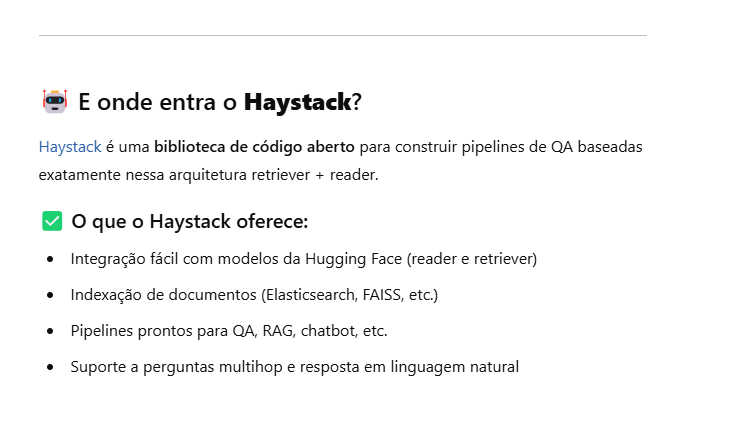

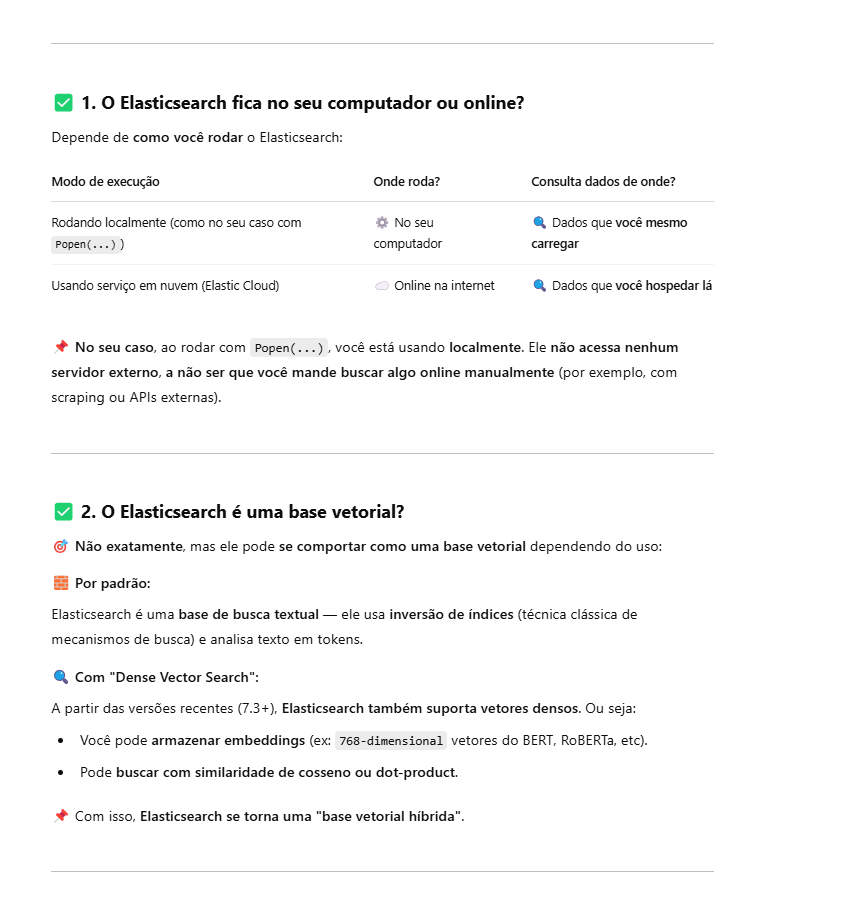

In [ ]:

#To initialize the document store, we first need to download and install Elasticsearch
url = """https://artifacts.elastic.co/downloads/elasticsearch/\
elasticsearch-7.9.2-linux-x86_64.tar.gz"""
!wget -nc -q {url}
!tar -xzf elasticsearch-7.9.2-linux-x86_64.tar.gz

# vamos explorar tanto sparse quanto dense retrievers
# por isso vmaos usar o elasticsearch, que e compativel com os dois

In [ ]:
import os
from subprocess import Popen, PIPE, STDOUT
# vamos inciar o server do elastic search
# Run Elasticsearch as a background process
# Altera o dono dos arquivos da pasta para o usuário daemon. Isso ajuda ao iniciar com permissões específicas.
!chown -R daemon:daemon elasticsearch-7.9.2
es_server = Popen(args=['elasticsearch-7.9.2/bin/elasticsearch'],
                  stdout=PIPE, stderr=STDOUT, preexec_fn=lambda: os.setuid(1))
# o popen tem como argumentos as especificações do programa que estmaos executando
# Wait until Elasticsearch has started
!sleep 30

In [ ]:
!pip install farm-haystack[colab]


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.9/153.9 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 MB 23.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.7/48.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 764.4/764.4 kB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 119.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 16.3 MB/s eta 0:00:00
  Created wheel for pillow: filename=Pillow-9.0.0-cp311-cp311-linux_x86_64.whl size=1177683 sha256=d16be4a7d486edec0e8af1655b6

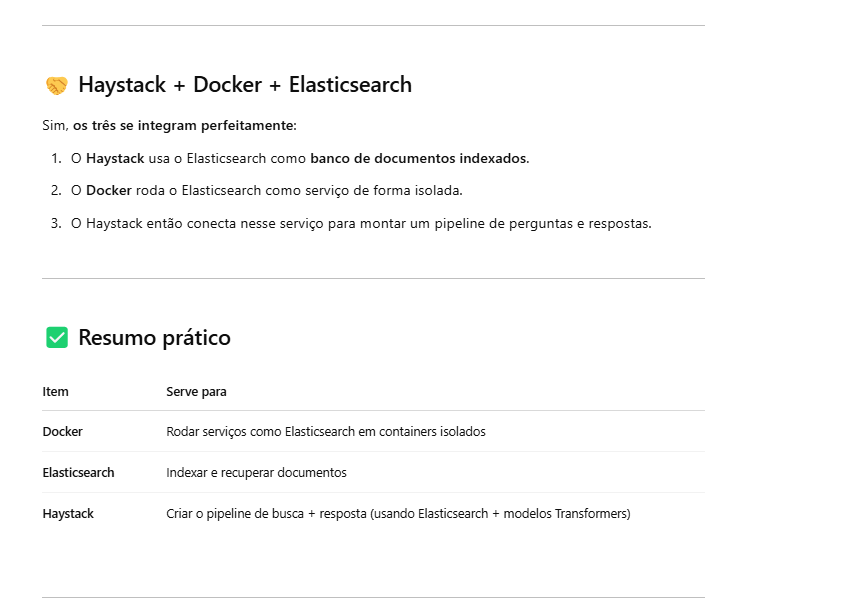

In [ ]:
# Alternative if Docker is installed ( aqui ele executa pelo docker)
# uma alternativa para rodar sem erros
#	launch_es() O Haystack baixa e executa o Elasticsearch via Docker automaticamente. Mais limpo e menos propenso a erros.
from haystack.utils import launch_es

launch_es()

In [ ]:
!curl -X GET "localhost:9200/?pretty"

{
  "name" : "e403d9779dab",
  "cluster_name" : "elasticsearch",
  "cluster_uuid" : "66NuU4f4TOeo6FTBHGuDpA",
  "version" : {
    "number" : "7.9.2",
    "build_flavor" : "default",
    "build_type" : "tar",
    "build_hash" : "d34da0ea4a966c4e49417f2da2f244e3e97b4e6e",
    "build_date" : "2020-09-23T00:45:33.626720Z",
    "build_snapshot" : false,
    "lucene_version" : "8.6.2",
    "minimum_wire_compatibility_version" : "6.8.0",
    "minimum_index_compatibility_version" : "6.0.0-beta1"
  },
  "tagline" : "You Know, for Search"
}


In [ ]:

# vamos instanciar a document store no elastic search

from haystack.document_stores.elasticsearch import ElasticsearchDocumentStore

# Return the document embedding for later use with dense retriever
document_store = ElasticsearchDocumentStore(return_embedding=True)

ImportError: Failed to import 'elasticsearch'. Run 'pip install farm-haystack[elasticsearch]'.
Note that this installs the Elasticsearch 7 client and requires a running Elasticsearch 7 instance. Starting from Haystack version 1.21 , the 'elasticsearch' extra will install the Elasticsearch 8 client and will require a running Elasticsearch 8 instance. To continue using Elasticsearch 7 with Haystack 1.21 and beyond, install the 'elasticsearch7' extra.
If you want to already start using Elasticsearch 8, install the 'elasticsearch8' extra. Original error: No module named 'elasticsearch'

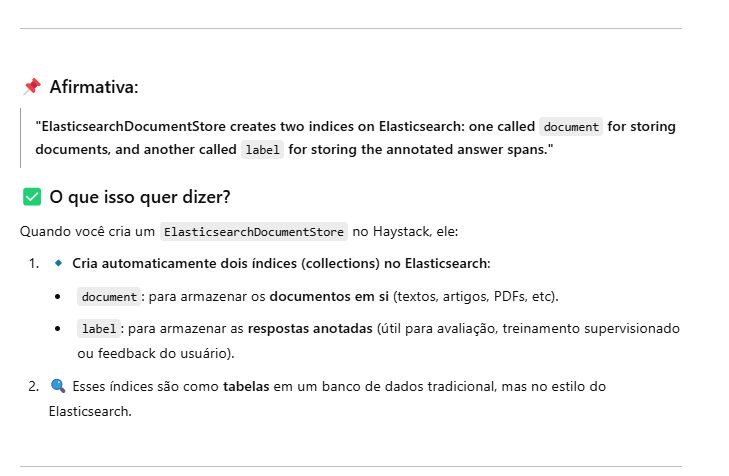

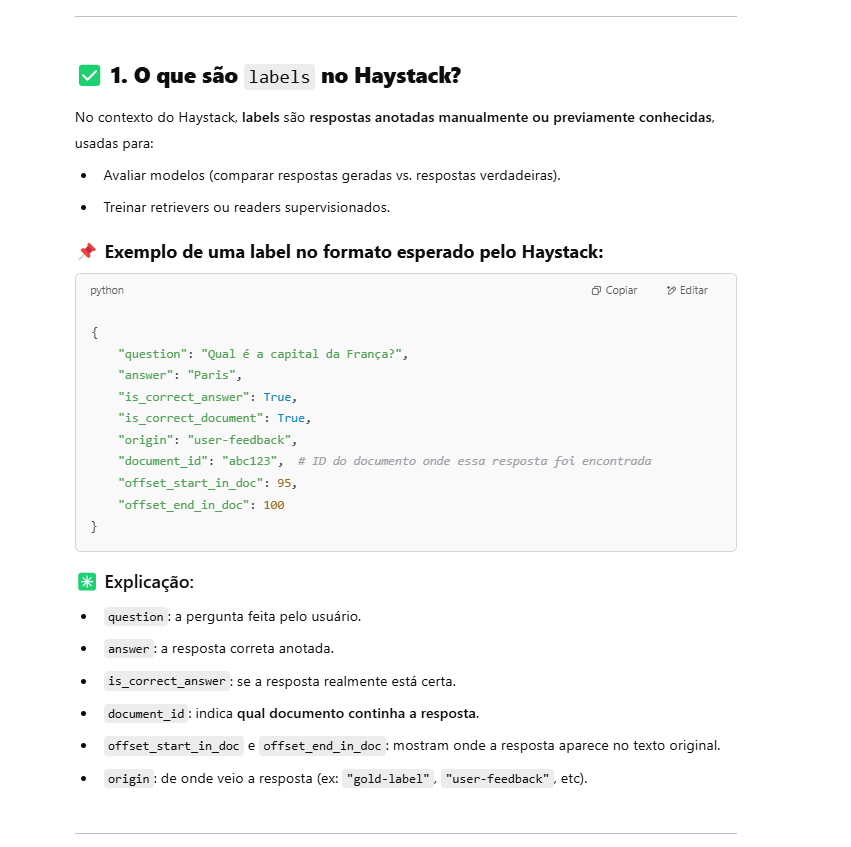

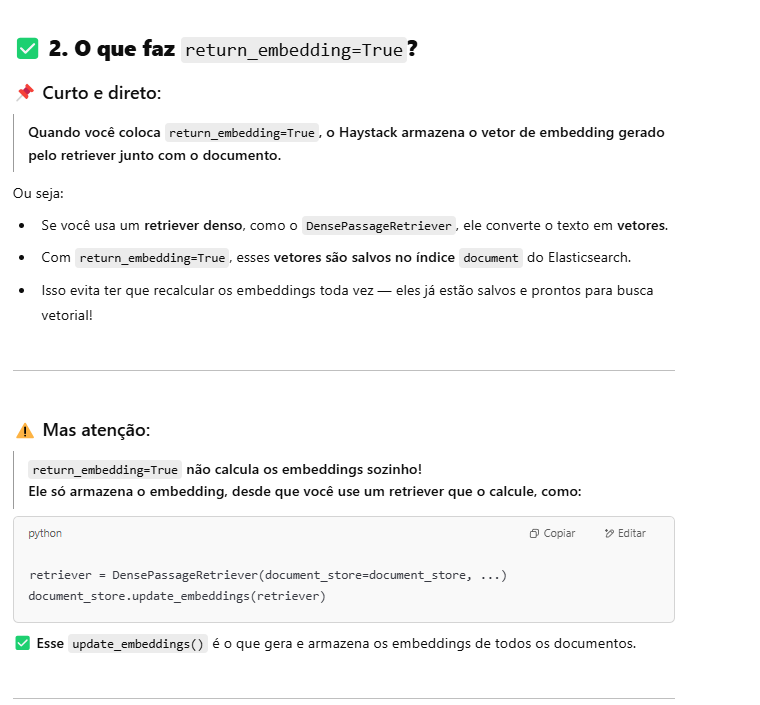

In [ ]:
# It's a good idea to flush Elasticsearch with each notebook restart
# as versoes mais novas usam document e label e nao text e meta como nav versao antiga
if len(document_store.get_all_documents()) or len(document_store.get_all_labels()) > 0:
    document_store.delete_documents(index="document")
    document_store.delete_documents(index="label")

Since version 1.0 of Haystack, Documents now have a field `content`, which replaces the field `text`. This change was introduced because Documents have become more flexible and can also store tables in addition to texts.

In [ ]:
# vamos adicionar metadados no context para podermos filtrar as informações no retrieval
# Isso é muito importante
for split, df in dfs.items():
    # Exclude duplicate reviews
    # vamos criar um dicionario de metadados meta
    # para o nosso caso de reiviews precisamos de informações para filtrar as buscas
    # isso porque por exemplo se a pergunta é de uma camera, precisamos dizer ao retriever de que item estamos falando
    #senao ele pode fazer uma busca contextual em produtos fora do interesse
    docs = [{"content": row["context"], "id": row["review_id"],
             "meta":{"item_id": row["title"], "question_id": row["id"],
                     "split": split}}
        for _,row in df.drop_duplicates(subset="context").iterrows()] # veja que aqui criamos docs

#agora vamos armazenar esses documentos na elastic document com index document
# vai virar um documento pesquisavel
    document_store.write_documents(documents=docs, index="document")

# vamos ver quantos documentos fora para o elastic search
print(f"Loaded {document_store.get_document_count()} documents")

#Vai dataframe por dataframe (train, test, etc.).

#Extrai o campo "context" e monta o meta com item_id, question_id, e split.

#Escreve esses documentos no índice "document" usando write_documents.



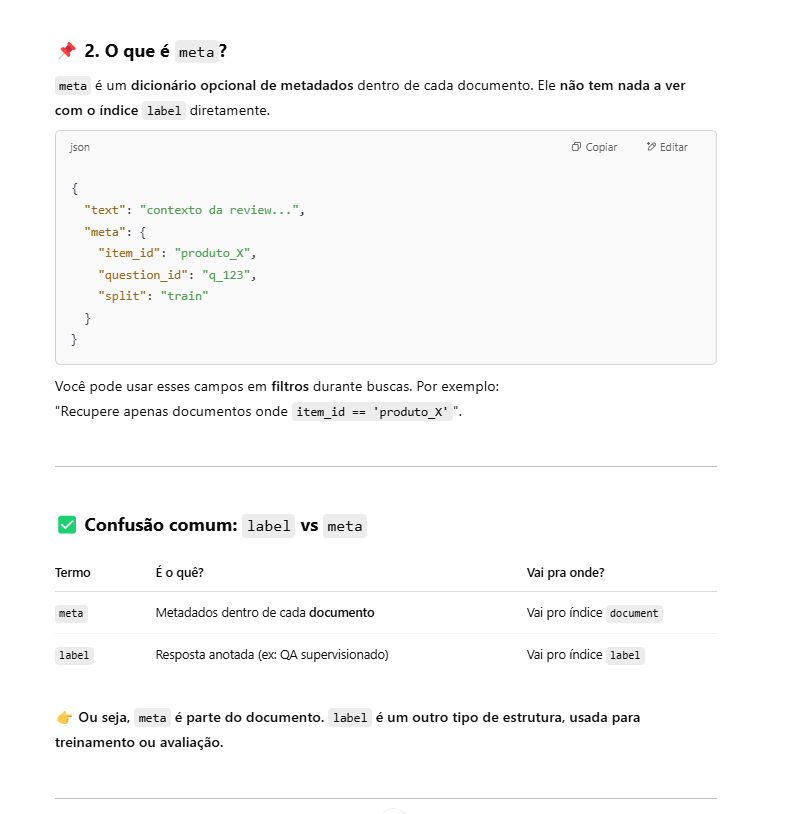

#### Initializing a retriever
**Para fazermos as buscas no elastic search vamos precisar de um retriever**

In Haystack 1.4 `ElasticsearchRetriever` was renamed to `BM25Retriever`. You can still use `ElasticsearchRetriever` for compatibility reasons in version 1.5 but it might be removed in future releases.

In [ ]:
# vamos começar com um sparse retriever BM25 (baseado em TF IDF)
from haystack.nodes.retriever import BM25Retriever
# vamos especificar a base de dados em que vamos fazer a pesquisa
bm25_retriever = BM25Retriever(document_store=document_store)

In [ ]:
# passamos informações do item para melhorar a busca
#é essencial em busca de produtos

# agora vamos teestar
item_id = "B0074BW614"
query = "Is it good for reading?"
retrieved_docs = bm25_retriever.retrieve(
    query=query, top_k=3, filters={"item_id":[item_id], "split":["train"]})

In [ ]:
print(retrieved_docs[0])
# vamos ver a primeira saida

# veja que o elastic search disponibiliza tambem o score alcançado

#### Initializing a reader

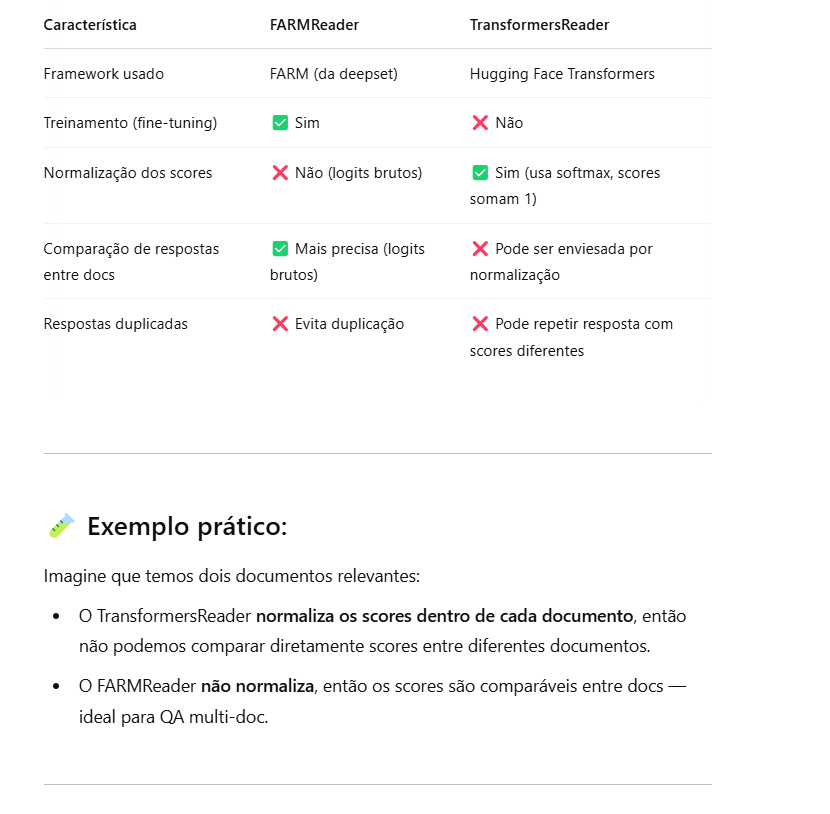

In [ ]:
from haystack.nodes import FARMReader
# o farmreader permite o fine tuning do modelo, mas nao usaremos agora
model_ckpt = "deepset/minilm-uncased-squad2" #alternative larger models: deepset/roberta-base-squad2-distilled or deepset/xlm-roberta-large-squad2 or the tiny distilled model: deepset/tinyroberta-squad2
max_seq_length, doc_stride = 384, 128
# docstride é o quanto as janelas se sobrepoe dentro do contexto
reader = FARMReader(model_name_or_path=model_ckpt, progress_bar=False,
                    max_seq_len=max_seq_length, doc_stride=doc_stride,
                    return_no_answer=True)

# return no answer = true Faz com que o modelo considere a possibilidade de não haver uma resposta no documento.

In [ ]:
print(reader.predict_on_texts(question=question, texts=[context], top_k=1))

#### Putting it all together

**Vamos criar um pipeline para executar todo o processo**

In [ ]:
from haystack.pipelines import ExtractiveQAPipeline
# o reader e retriever ja foram definidos
#pipe = ExtractiveQAPipeline(reader=reader, retriever=bm25_retriever)

The format of parameters that can be passed to a pipeline has slightly changed. In the old version, the method call was
```python
preds = pipe.run(query=query, top_k_retriever=3, top_k_reader=n_answers,
                 filters={"item_id": [item_id], "split":["train"]})
```
Now, you can specify the name of the node, e.g., `"Retriever"`, that you want to pass parameters to.

In [ ]:
# vamos gerar agora as respostas
n_answers = 3
preds = pipe.run(query=query, params={"Retriever": {"top_k": 3, "filters":{"item_id": [item_id], "split":["train"]}},
                                      "Reader": {"top_k": n_answers}})

# vamos testar com a query que definimos 'is it good for reading?''
# vamos gerar 3 respostas (n_answers = 3)
print(f"Question: {preds['query']} \n")

for idx in range(n_answers):
    print(f"Answer {idx+1}: {preds['answers'][idx].answer}")
    print(f"Review snippet: ...{preds['answers'][idx].context}...")
    print("\n\n")

## Improving Our QA Pipeline

### Evaluating the Retriever
A common metric for evaluating retrievers is recall, which measures the fraction of all relevant documents that are retrieved.In this context, “relevant” simply means whether the answer is present in a passage of text or not.counting the number of times an answer appears in the top k documents returned by the retriever

Evaluating the retriever is the same as evaluating a `DocumentSearchPipeline`, which consists only of a single node, a retriever.

In [ ]:
from haystack.pipelines import DocumentSearchPipeline

pipe = DocumentSearchPipeline(retriever=bm25_retriever)

Since version 1.0 of Haystack, `Answer` has become a class and each `Label` contains a `Document` that the `Label` refers to. Thus, the initialization of a `Label` in the following code cell has changed.
Note that the code printed in the book had a small bug. In the for loop of the old code, `Label`s were created that were all initialized with the same id. Thus they were handled as duplicates and not all of them were stored in the document store when we later on called `document_store.write_labels(labels, index="label")`:
```python
for answer in row["answers.text"]:
            label = Label(
                question=row["question"], answer=answer, id=i, origin=row["id"],
                meta=meta, is_correct_answer=True, is_correct_document=True,
                no_answer=False)
            labels.append(label)
```


*In the previous version there was a bug that omitted some of the labels.*

In [ ]:
#Criar uma lista de objetos Label, que representam exemplos de teste que contêm a pergunta, a resposta correta, o contexto e metadados.
#Essa lista é usada depois para avaliar a performance do pipeline (retriever + reader).

from haystack import Label, Answer, Document
# vamos preparar os dados para o pipeline de avaliaçao do RAG

labels = []
for i, row in dfs["test"].iterrows():# cada linha contem question, answer.text,context (review)e metadados (review id, title,id)
    # Metadata used for filtering in the Retriever
    #Esses metadados serão usados para filtragem no Retriever
    # eles estao sendo criados e serao inseridos nas caracteristicas
    meta = {"item_id": row["title"], "question_id": row["id"]}
    # Populate labels for questions with answers
    if len(row["answers.text"]):
    # para cada resposta, vamos criar uma label
    # vamos criar agora as respostas
    #is_correct_answer=True: sinaliza que essa resposta está correta.
    #is_correct_document=True: o contexto fornecido contém a resposta.
    #no_answer=False: está esperando uma resposta.
    #filters: define que esse label só deve ser avaliado com documentos do mesmo item e do split "test".
        for answer in row["answers.text"]:
            label = Label(
                query=row["question"], answer=Answer(answer=answer), origin="gold-label",
                document=Document(content=row["context"], id=row["review_id"]),
                meta=meta, is_correct_answer=True, is_correct_document=True,
                no_answer=False, filters={"item_id": [meta["item_id"]], "split":["test"]})
            labels.append(label)
#origin="gold-label": marca esse rótulo como resposta verdadeira (vinda do dataset).
    # Populate labels for questions without answers
#CASO A PERGUNTA NAO TENHA RESPOSTAS
    else:
        label = Label(
            query=row["question"], answer=Answer(answer=""), origin="gold-label", document=Document(content=row["context"], id=row["review_id"]),
            meta=meta, is_correct_answer=True, is_correct_document=True,
            no_answer=True, filters={"item_id": [row["title"]], "split":["test"]})
        labels.append(label)

        #Aqui, no_answer=True: indica que não há uma resposta correta no documento.

#Isso é importante para o Reader aprender a "não responder" em certos contextos.

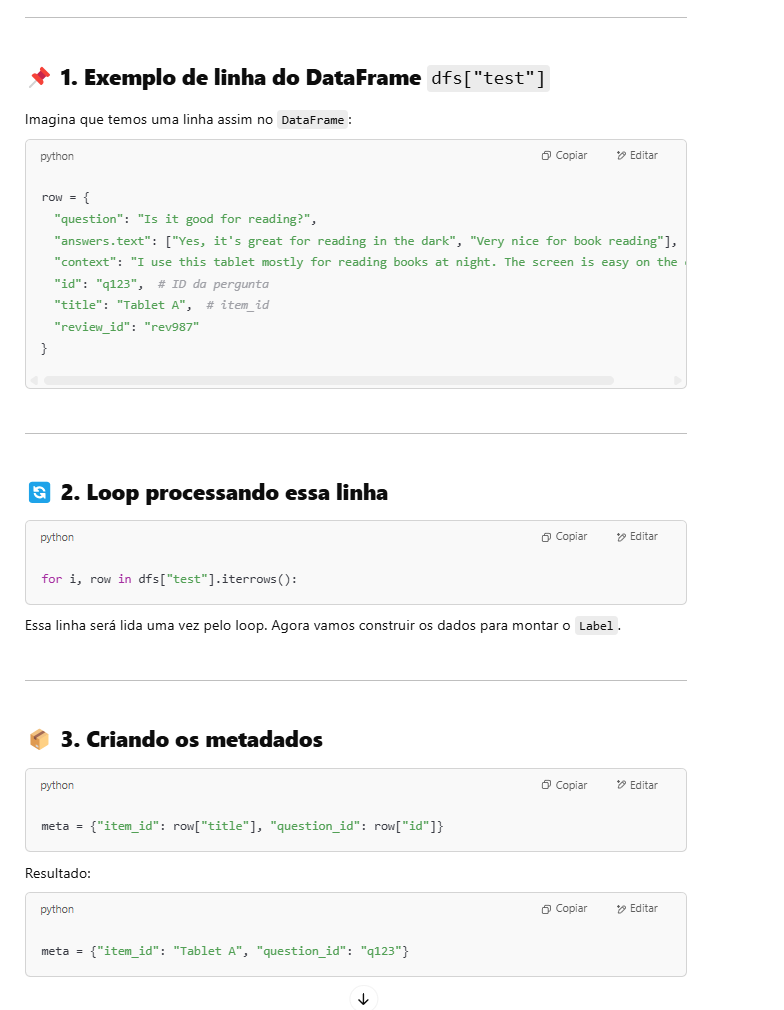

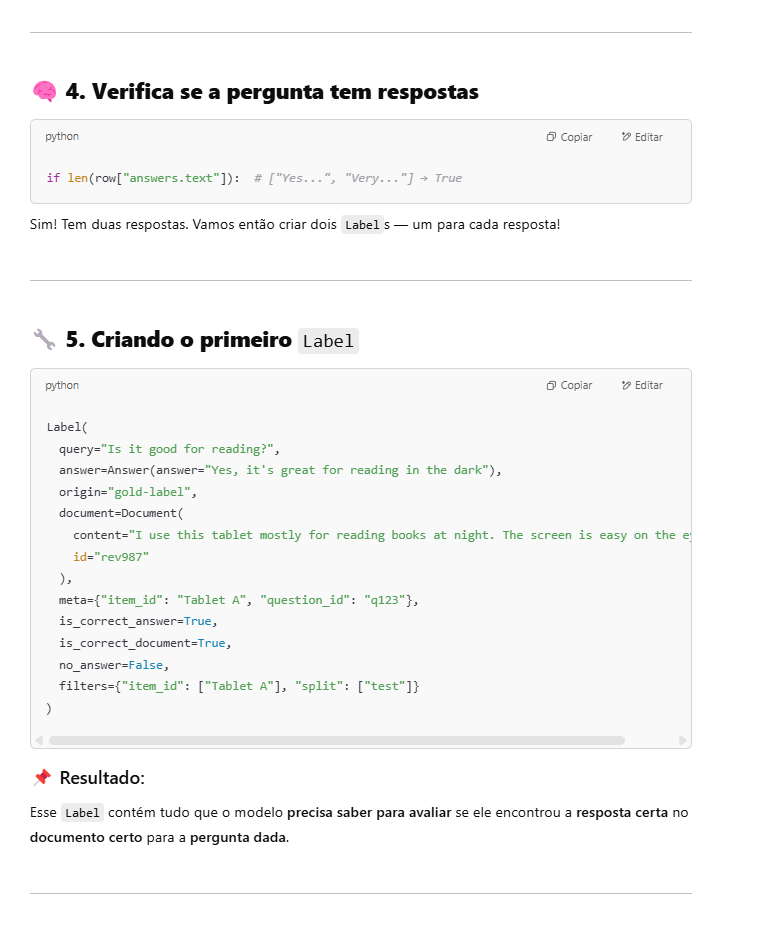

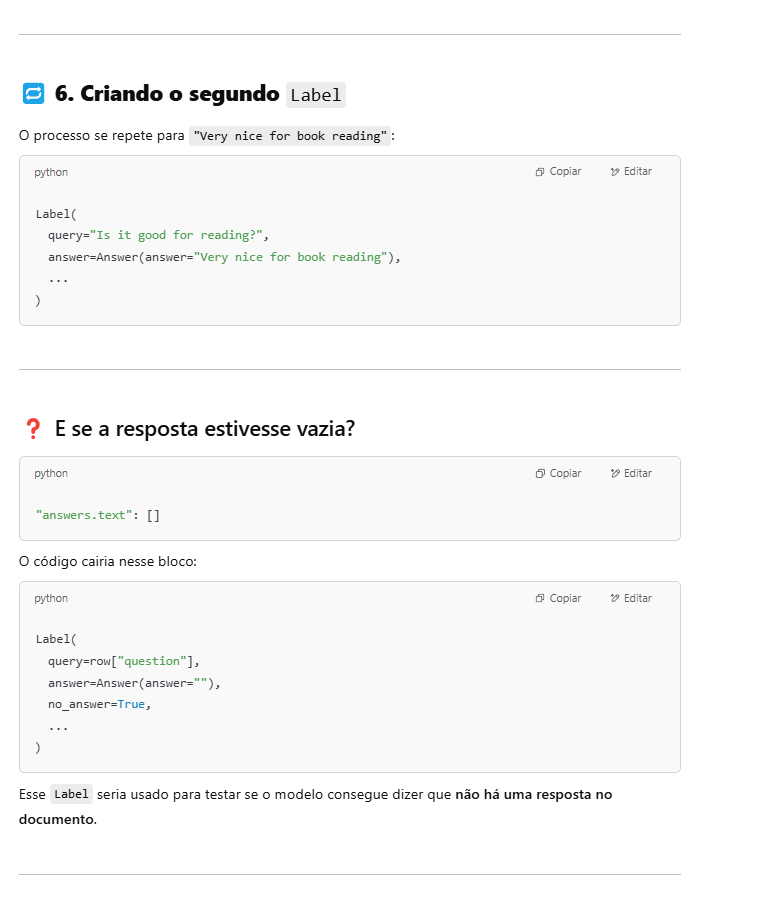

In [ ]:
document_store.write_labels(labels, index="label")
# vamos colocar nossas labels que criamos no elastic search
print(f"""Loaded {document_store.get_label_count(index="label")} \
question-answer pairs""")

Next, we need to build up a mapping between our question IDs and corresponding answers that we can pass to the pipeline. To get all the labels, we can use the get_all_labels_aggregated() method from the document store that will aggregate all question-answer pairs associated with a unique ID. This method returns a list of MultiLabel objects, but in our case we only get one element since we’re filtering by question ID. We can build up a list of aggregated labels as follows:

In [ ]:
# vamos agregar as labels pelo nosso item_id, assim as buscas serao mais direcionadas
labels_agg = document_store.get_all_labels_aggregated(
    index="label",
    open_domain=True,
    aggregate_by_meta=["item_id"]
)
print(len(labels_agg))

Since version 1.0 of Haystack, the evaluation of pipelines is much different compared to the version described in the first edition of the book. `Pipeline` now has a method `eval()`, which runs the pipeline given input data from labels and returns the prediction and the labels in the format of one Pandas dataframe per pipeline node. This result is stored in `eval_result` in the following code cell. On these results, we can calculate arbitrary metrics - without rerunning the computationally intesive inference steps of the pipeline.

In [ ]:
# We can run the pipeline with the desired top_k value like this
eval_result = pipe.eval(
    labels=labels_agg,
    params={"Retriever": {"top_k": 3}},
)
#Usa os Label agregados como base de verdade (gold truth).
#Roda o pipeline RAG (Retriever + Reader) simulando perguntas reais.
#top_k=3: o retriever trará os 3 documentos mais relevantes para cada pergunta.


metrics = eval_result.calculate_metrics()

#📌 O que faz? Calcula as métricas com base nos resultados do eval, como:

#Precision: % de respostas corretas entre todas as retornadas.

#Recall: % de respostas corretas que foram realmente recuperadas.

#F1: média harmônica entre precisão e recall.

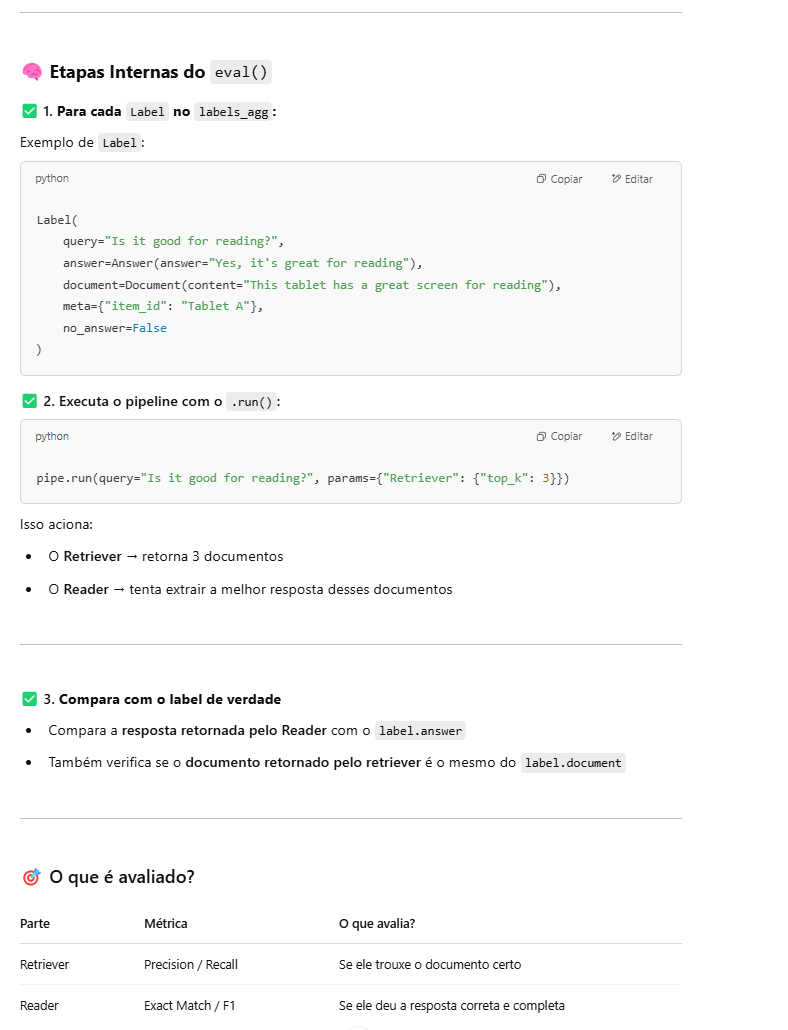

In [ ]:
print(f"Recall@3: {metrics['Retriever']['recall_single_hit']:.2f}")

You can check the predictions of any query by inspecting the dataframe:

In [ ]:
eval_df = eval_result["Retriever"]
eval_df[eval_df["query"] == "How do you like the lens?"][["query", "filters", "rank", "content", "gold_document_contents", "document_id", "gold_document_ids", "gold_id_match"]]

Or if we want to calculate metrics for multiple topk values, we can run the pipeline only once with the highest top_k value and calculate metrics for smaller top_ks afterwards.

**Great, it works! Notice that we picked a specific value for top_k_retriever to specify the number of documents to retrieve. In general, increasing this parameter will improve the recall, but at the expense of providing more documents to the reader and slowing down the end-to-end pipeline. To guide our decision on which value to pick, we’ll create a function that loops over several k values and compute the recall across the whole test set for each k:**

In [ ]:
def evaluate_retriever(retriever, topk_values = [1,3,5,10,20]):
    topk_results = {}
    # Calculate max top_k
    max_top_k = max(topk_values)
    # Create Pipeline
    p = DocumentSearchPipeline(retriever=retriever)
    # Run inference with max top_k by looping over each question-answers pair in test set
    eval_result = p.eval(
        labels=labels_agg,
        params={"Retriever": {"top_k": max_top_k}},
    )
    # Calculate metric for each top_k value
    for topk in topk_values:
        # Get metrics
        metrics = eval_result.calculate_metrics(simulated_top_k_retriever=topk)
        topk_results[topk] = {"recall": metrics["Retriever"]["recall_single_hit"]}

    return pd.DataFrame.from_dict(topk_results, orient="index")


bm25_topk_df = evaluate_retriever(bm25_retriever)

In [ ]:
# vamos plotar o grafico e decitir o nosso topk
def plot_retriever_eval(dfs, retriever_names):
    fig, ax = plt.subplots()
    for df, retriever_name in zip(dfs, retriever_names):
        df.plot(y="recall", ax=ax, label=retriever_name)
    plt.xticks(df.index)
    plt.ylabel("Top-k Recall")
    plt.xlabel("k")
    plt.show()

plot_retriever_eval([bm25_topk_df], ["BM25"])

#### Dense Passage Retrieval
A well-known limitation of sparse retrievers like BM25 is that they can fail to capture the relevant documents if the user query contains terms that don’t match exactly those of the review. One promising alternative is to use dense embeddings to represent the question and document, and the current state of the art is an architecture known as Dense Passage Retrieval (DPR). The main idea behind DPR is to use two BERT models as encoders for the question and the passage.

<img alt="DPR Architecture" caption="DPR's bi-encoder architecture for computing the relevance of a document and query" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter07_dpr.png?raw=1" id="dpr"/>

In [ ]:
# vamos agora criar um dense vector como técnica de embedding
from haystack.nodes import DensePassageRetriever

# podemos usar o haystack para isso, indicando o local onde está a documentação, o modelo usado para
#embedar a query e o modelo para embedar a passagem
# geralmetne são os mesmos, mas para o QA temos dois embeddings treinados especificamente para cada casp
dpr_retriever = DensePassageRetriever(document_store=document_store,
    query_embedding_model="facebook/dpr-question_encoder-single-nq-base",
    passage_embedding_model="facebook/dpr-ctx_encoder-single-nq-base",
    embed_title=False)
# embed_title=False indica que o titulo nao contem nenhuma informação adicional (ja que vamos segregar por produtos)
#logo ele nao será embedado

In [ ]:
document_store.update_embeddings(retriever=dpr_retriever)
#Once we’ve initialized the dense retriever, the next step is to iterate over all the
#indexed documents in our Elasticsearch index and apply the encoders to update the embedding representation.

In [ ]:
# agora vamos avaliar o dense retriever assim como fizemos com o bm25
# a função evaluate retriever foi criada acima
dpr_topk_df = evaluate_retriever(dpr_retriever)
plot_retriever_eval([bm25_topk_df, dpr_topk_df], ["BM25", "DPR"])

**Performing similarity search of the embeddings can be sped up by using Facebook’s FAISS library as the document store. Similarly, the performance of the DPR retriever can be improved by fine-tuning on the target domain. If you’d like to learn how to fine-tune DPR, check out the Haystack tutorial**

### Evaluating the Reader

In extractive QA, there are two main metrics that are used for evaluating readers:

**Exact Match (EM)**

A binary metric that gives EM = 1 if the characters in the predicted and ground truth answers match exactly, and EM = 0 otherwise. If no answer is expected, the model gets EM = 0 if it predicts any text at all.

**F1-score**

Measures the harmonic mean of the precision and recall.

In [ ]:
from haystack.modeling.evaluation.squad import compute_f1, compute_exact
# vamos ver como essas metricas funcionam
# ESSAS FUNÇÕES AUTOMATICAMENTE REMOVEM PONTOS, ESPAÇOS EXTRAS E COLOCAM TUDO EM MINUSCULA
pred = "about 6000 hours"
label = "6000 hours"
print(f"EM: {compute_exact(label, pred)}")
print(f"F1: {compute_f1(label, pred)}")

#em vai ser zero e f1 0.8

In [ ]:
pred = "about 6000 dollars"
print(f"EM: {compute_exact(label, pred)}")
print(f"F1: {compute_f1(label, pred)}")
# em 0 e f1 0.4

Relying on just the F -score is thus misleading, and tracking both metrics is a good strategy to balance the tradeoff between underestimating (EM) and overestimating (F -score) model performance

Now in general, there are multiple valid answers per question, so these metrics are calculated for each questionanswer pair in the evaluation set, and the best score is selected over all possible answers. The overall EM and F scores for the model are then obtained by averaging over the individual scores of each question-answer pair

The evaluation of a reader can be done by creating a pipeline that consists only of a single node: a reader. In this case, the `pipeline.eval()` gets the relevant documents as direct input from the labels.

In [ ]:
from haystack.pipelines import Pipeline
def evaluate_reader(reader):
    score_keys = ['exact_match', 'f1']
    p = Pipeline()
    p.add_node(component=reader, name="Reader", inputs=["Query"])

    eval_result = p.eval(
        labels=labels_agg,
        documents= [[label.document for label in multilabel.labels] for multilabel in labels_agg],
        params={},
    )
    metrics = eval_result.calculate_metrics(simulated_top_k_reader=1)

    return {k:v for k,v in metrics["Reader"].items() if k in score_keys}

reader_eval = {}
reader_eval["Fine-tune on SQuAD"] = evaluate_reader(reader)

In the first version no_answer labels weren't taken into account. Because there are quite many of them in the evaluation dataset the numbers differ significantly compared to the first version (EM was at ~0.07 and f1 at ~0.25).

In [ ]:
def plot_reader_eval(reader_eval):
    fig, ax = plt.subplots()
    df = pd.DataFrame.from_dict(reader_eval).reindex(["exact_match", "f1"])
    df.plot(kind="bar", ylabel="Score", rot=0, ax=ax)
    ax.set_xticklabels(["EM", "F1"])
    plt.legend(loc='upper left')
    plt.show()

plot_reader_eval(reader_eval)

### Domain Adaptation
Vamos aplicar um fine tuning no dataset e entender se a especializaçao de domínio melhora os resultados

Domain Adaptation

Although models that are fine-tuned on SQuAD will often generalize well to other domains, we’ve seen that for SubjQA the EM and F scores of our model were much worse than for SQuAD. This failure to generalize has also been observed in other extractive QA datasets and is understood as evidence that transformer models are particularly adept at overfitting to SQuAD. The most straightforward way to improve the reader is by fine-tuning our MiniLM model further on the SubjQA training set. The FARMReader has a train() method that is designed for this purpose and expects the data to be in SQuAD JSON format, where all the question-answer pairs are grouped together for each item as illustrated

<img alt="SQuAD Schema" caption="Visualization of the SQuAD JSON format" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter07_squad-schema.png?raw=1" id="squad-schema"/>

This is quite a complex data format, so we’ll need a few functions and some Pandas magic to help us do the conversion. The first thing we need to do is implement a function that can create the paragraphs array associated with each product ID

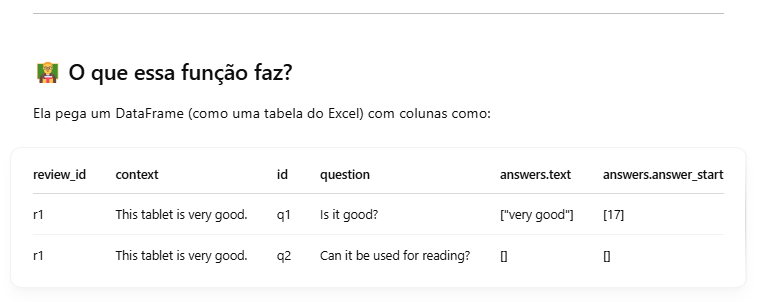

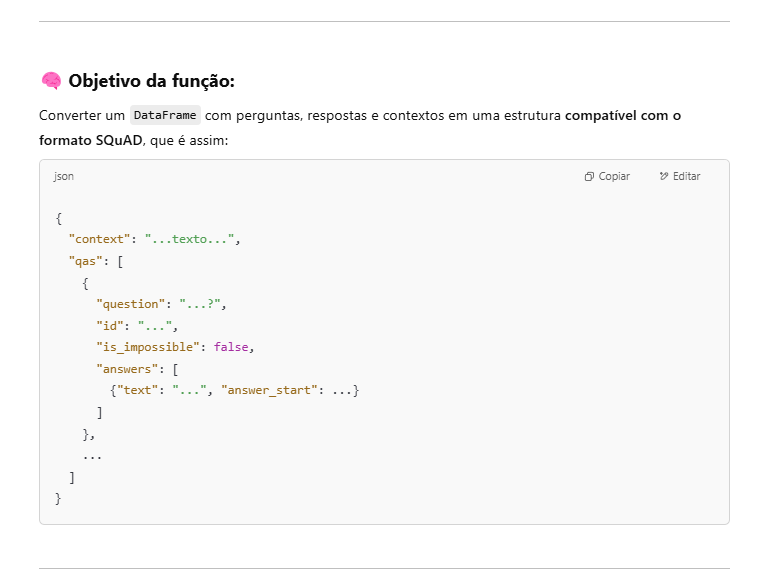

In [ ]:


def create_paragraphs(df): # ESSA FUNÇAO RECEBE UM DATAFRAME
  #Cria uma lista paragraphs onde cada elemento será um parágrafo SQuAD.
  # Cada paragrafo contem um contexto e dentro do contexto temos as perguntas e as respostas
    paragraphs = []
    #id2context: mapeia cada review_id para seu context (texto da resenha).
    # ou seja pegamos review id e context e criamos um dicionario onde cada review id
    # aponta para seu texto
    id2context = dict(zip(df["review_id"], df["context"]))
    for review_id, review in id2context.items():

      #Para cada review (ou seja, para cada contexto textual),
      #criamos uma lista qas com todas as perguntas sobre ele.
        qas = []
        # Filter for all question-answer pairs about a specific context
        #Filtra todas as perguntas e respostas relacionadas ao review atual
        review_df = df.query(f"review_id == '{review_id}'") # voltamos ao dataset para pegar as questoes
        #id2question: mapeia o ID da pergunta (id) para o texto da pergunta (question).

        id2question = dict(zip(review_df["id"], review_df["question"]))
        # Build up the qas array
        # para cada pergunta pega todas as informações dela e transforma em um dicionario
        for qid, question in id2question.items(): #qid é o ID da pergunta.
            # Filter for a single question ID
            #question_df busca todas as respostas associadas àquela pergunta.

            #Você transforma o DataFrame filtrado para aquela pergunta em um dicionário, onde:
            #Cada chave é uma coluna do DataFrame
            #Cada valor é uma lista com todos os valores daquela coluna
            question_df = df.query(f"id == '{qid}'").to_dict(orient="list")
            #Extrai a posição inicial (answer_start) e o texto da resposta (text)
            #de cada resposta associada àquela pergunta.
            ans_start_idxs = question_df["answers.answer_start"][0].tolist()
            #se não fizer [0], você fica com uma lista dentro de outra lista.
            # isso porque já era uma lista e foi transformado em dicionario com orientação de lista
            # é o texto d resposta
            ans_text = question_df["answers.text"][0].tolist()
            # Fill answerable questions

            # se tiver um resposta criamos uma lista e respostas
            # e se nao tiver colocamos is_impossible = True
            if len(ans_start_idxs):
                answers = [
                    {"text": text, "answer_start": answer_start}
                    for text, answer_start in zip(ans_text, ans_start_idxs)]
                is_impossible = False
            else:
              #Se estiver vazio, é uma pergunta sem resposta — usada em QA para
              # treinamento com is_impossible = True.
                answers = []
                is_impossible = True
            # Add question-answer pairs to qas
            qas.append({"question": question, "id": qid,
                        "is_impossible": is_impossible, "answers": answers})
        # Add context and question-answer pairs to paragraphs
        #Adiciona o texto (review) e todas as suas perguntas no formato final SQuAD.
        paragraphs.append({"qas": qas, "context": review})
    return paragraphs

In [ ]:
#vamos aplicar essa preparação de texto a apenas um id de produto para visualizar
product = dfs["train"].query("title == 'B00001P4ZH'")
create_paragraphs(product)

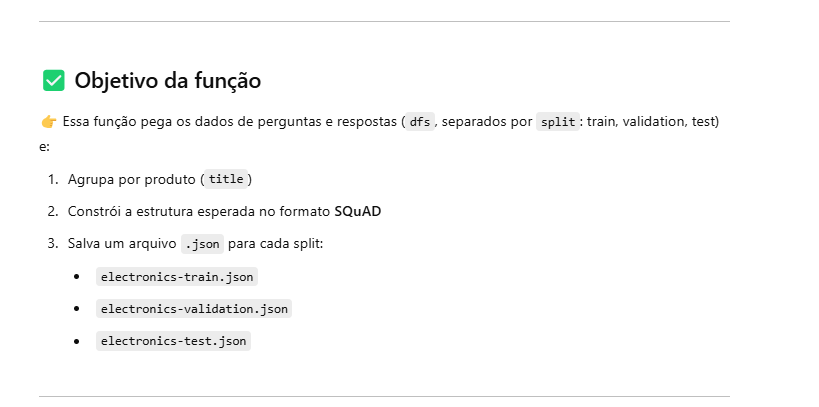

In [ ]:
import json
# sera aplicado a cada produto
# agora vamos aplicar para cada split e salvar como json (formato exigido)
# dfs é um dicionário onde cada chave é um split (ex: 'train', 'validation', 'test')
# e o valor é um DataFrame com as perguntas/respostas daquele split.
def convert_to_squad(dfs):
  # Iteramos sobre cada split e seu respectivo DataFrame.
    for split, df in dfs.items():
        subjqa_data = {}
        # Create `paragraphs` for each product ID
        groups = (df.groupby("title").apply(create_paragraphs)
            .to_frame(name="paragraphs").reset_index())
        # transformamos o groups inteiro num dicionário
        subjqa_data["data"] = groups.to_dict(orient="records")

    #Agrupamos o DataFrame por title (produto)
    #Para cada grupo, aplicamos create_paragraphs(df)
    #Depois, transformamos o resultado numa coluna chamada "paragraphs"
    #E usamos reset_index() para que o índice volte a ser numéric
        # Save the result to disk
        with open(f"electronics-{split}.json", "w+", encoding="utf-8") as f:
            json.dump(subjqa_data, f)

convert_to_squad(dfs)

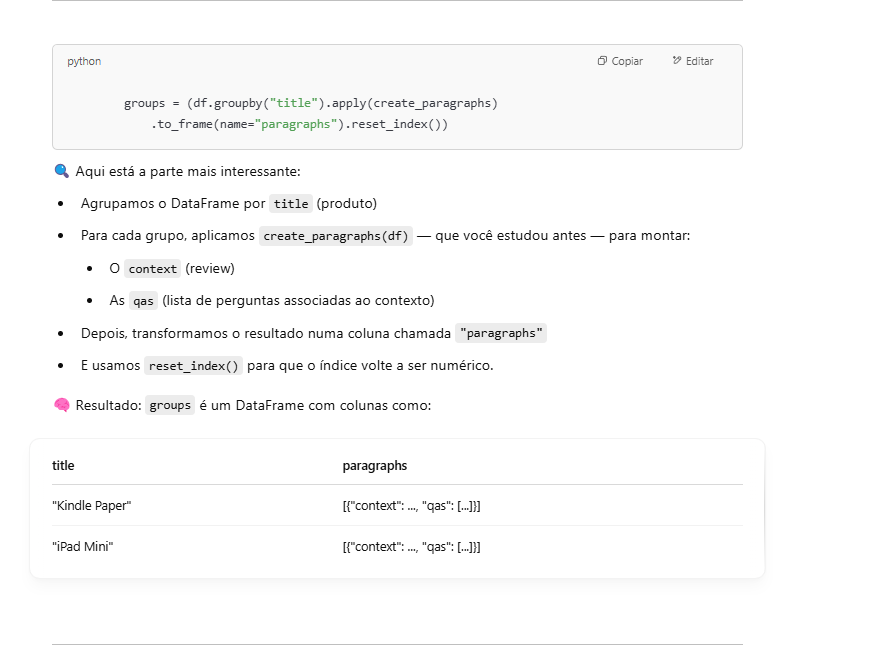

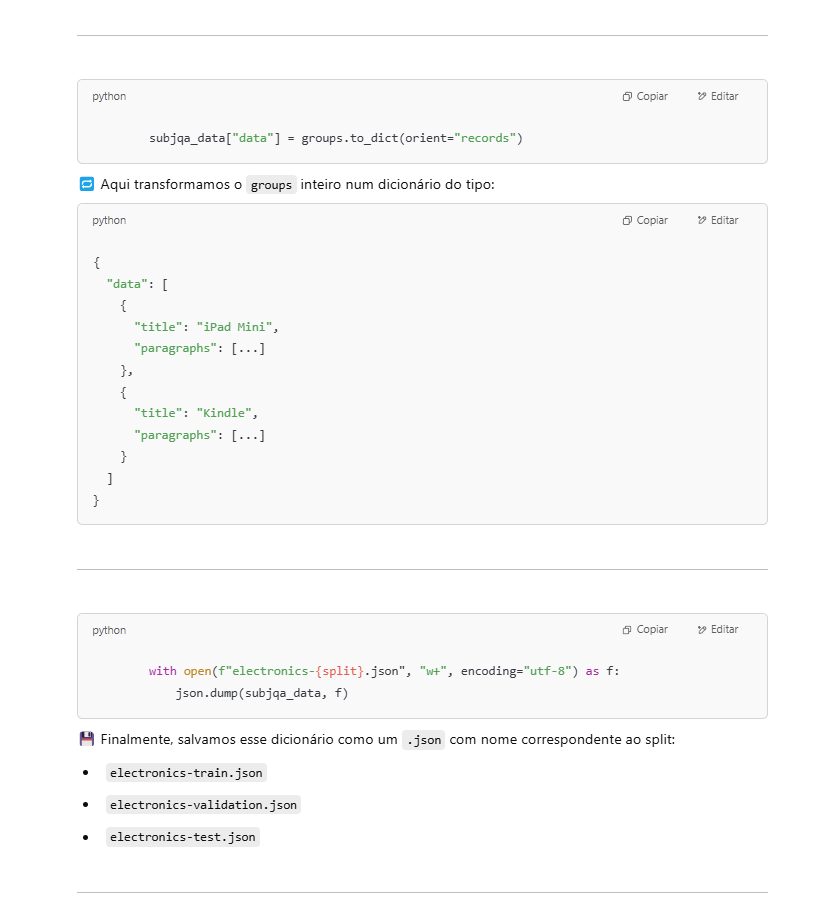

In [ ]:
# agora que temos nosso formato correto vamos fazer o fine tuning do reader
#primeiro especificamos o local de treino e de dev slits

train_filename = "electronics-train.json"
dev_filename = "electronics-validation.json"

reader.train(data_dir=".", use_gpu=True, n_epochs=1, batch_size=16,
             train_filename=train_filename, dev_filename=dev_filename)

In [ ]:
reader_eval["Fine-tune on SQuAD + SubjQA"] = evaluate_reader(reader)

In [ ]:
plot_reader_eval(reader_eval)

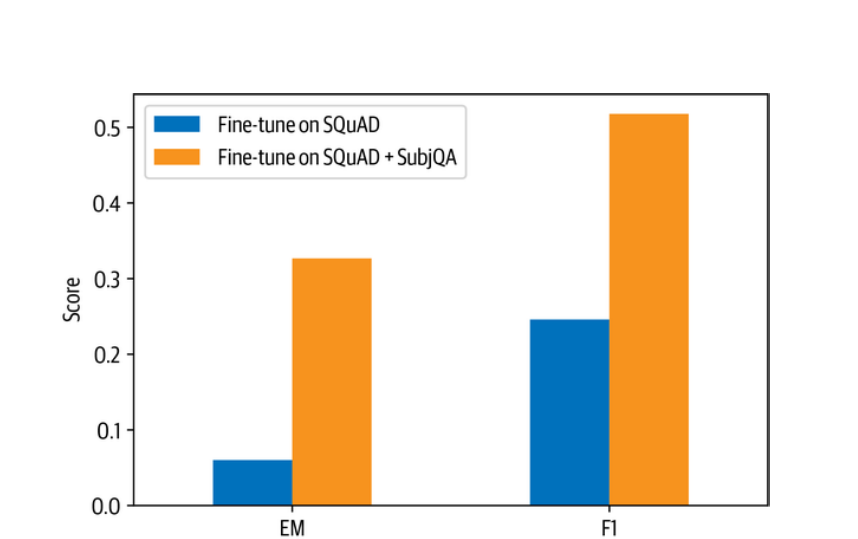

In [ ]:
minilm_ckpt = "microsoft/MiniLM-L12-H384-uncased"
minilm_reader = FARMReader(model_name_or_path=minilm_ckpt, progress_bar=False,
                           max_seq_len=max_seq_length, doc_stride=doc_stride,
                           return_no_answer=True)

**At this point, you might be wondering why we didn’t just fine-tune a pretrained language model directly on the SubjQA training set. One reason is that we only have 1,295 training examples in SubjQA while SQuAD has over 100,000, so we might run into challenges with overfitting. Nevertheless, let’s take a look at what naive fine-tuning produces. For a fair comparison, we’ll use the same language model that was used for fine-tuning our baseline on SQuAD. As before, we’ll load up the model with the FARMReader**

In [ ]:
minilm_reader.train(data_dir=".", use_gpu=True, n_epochs=1, batch_size=16,
             train_filename=train_filename, dev_filename=dev_filename)

In [ ]:
reader_eval["Fine-tune on SubjQA"] = evaluate_reader(minilm_reader)

In [ ]:
plot_reader_eval(reader_eval)

#Quanto menor o dataset, maior o risco de overfitting, então técnicas como:

#Uso de bases complementares (SQuAD)

#Cross-validation

#Regularização (menos epochs, dropout, etc)

#são altamente recomendadas.

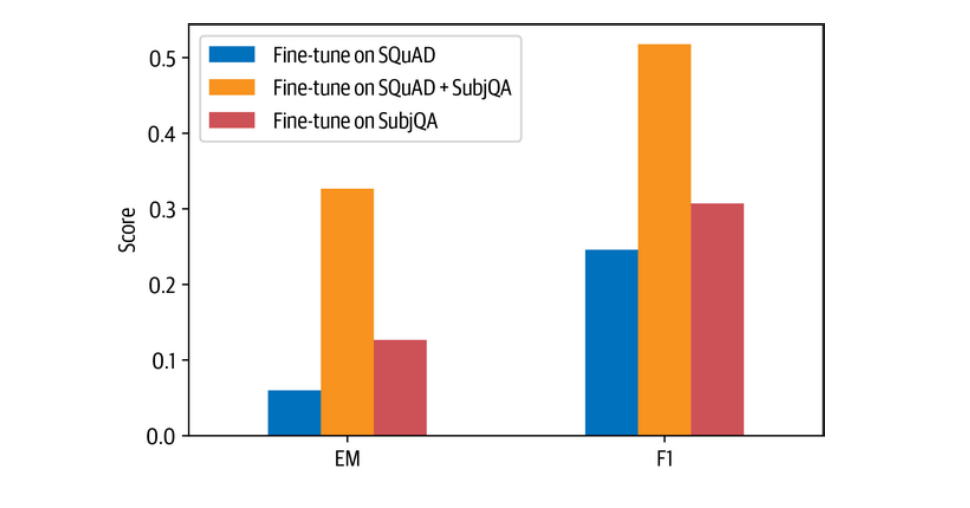

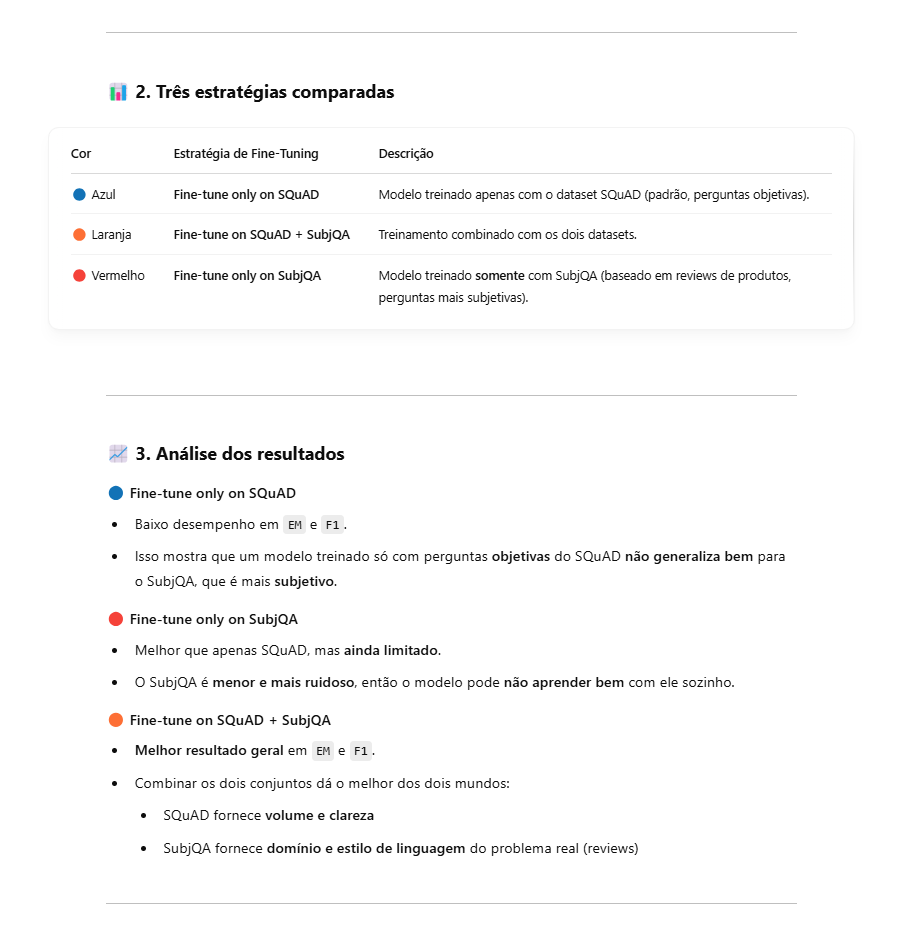

We can see that fine-tuning the language model directly on SubjQA results in considerably worse performance than fine-tuning on SQuAD and SubjQA.

When dealing with small datasets, it is best practice to use cross-validation when evaluating transformers as they can be prone to overfitting. You can find an example of how to perform cross-validation with SQuAD-formatted datasets in the FARM repository.

### Evaluating the Whole QA Pipeline


Now that we’ve seen how to evaluate the reader and retriever components individually, let’s tie them together to measure the overall performance of our pipeline. To do so, we’ll need to augment our retriever pipeline with nodes for the reader and its evaluation. We’ve seen that we get almost perfect recall at k = 10, so we can fix this value and assess the impact this has on the reader’s performance (since it will now receive multiple contexts per query compared to the SQuAD-style evaluation):


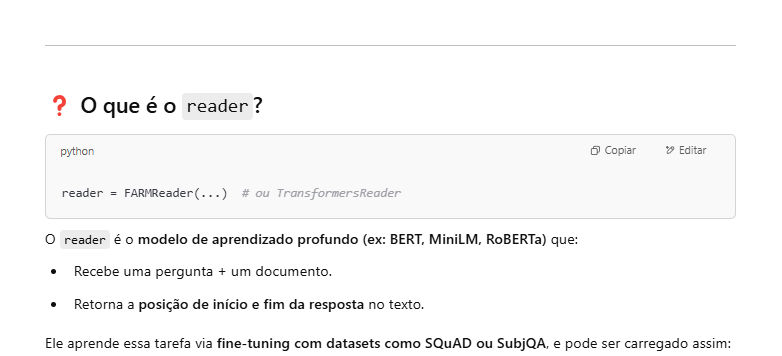

In [ ]:
#vamos fazer um pipeline de avaliaçao de um QA tando do retriever quanto do reader
from haystack.pipelines import ExtractiveQAPipeline
# conectamos o retriever e o modelo pre treinado de QA (reader)
pipe = ExtractiveQAPipeline(retriever=bm25_retriever, reader=reader)

# Evaluate!
# o eval para cada label usa o retriever para recuperar os docs relevantes baseados na pergunta
#passa os documentos para o reader
# o reader tenta encontrar o span da resposta dentro do texto
# o haystack compara a resposta predita com a label correta
# label é pergunta + resposta correta + contexto onde a resposta está
eval_result = pipe.eval(
    labels=labels_agg,
    params={},
)
metrics = eval_result.calculate_metrics(simulated_top_k_reader=1)
#avalie o desempenho do leitor considerando apenas a primeira resposta mais provável"
# Extract metrics from reader
reader_eval["QA Pipeline (top-1)"] = {
    k:v for k,v in metrics["Reader"].items()
    if k in ["exact_match", "f1"]}

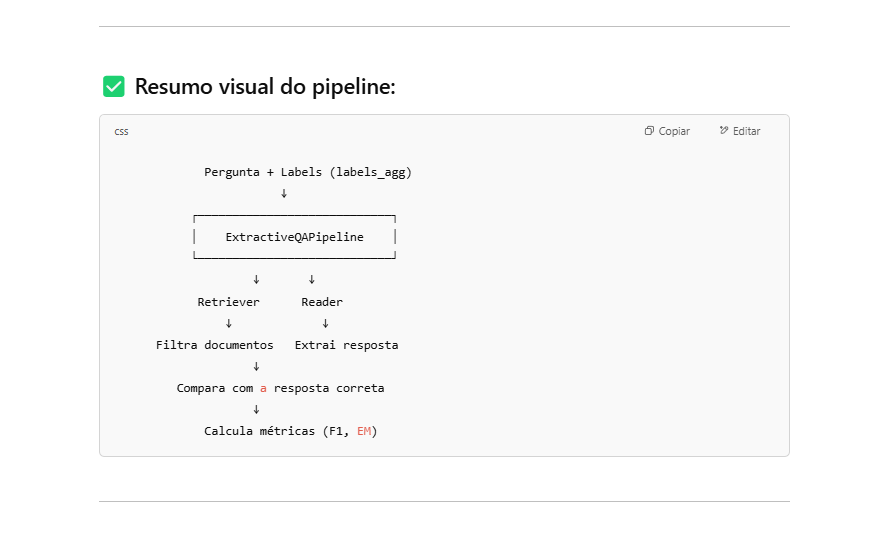

In [ ]:
#id reader-vs-pipeline
#caption Comparison of EM and _F_~1~ scores for the reader against the whole QA pipeline
plot_reader_eval({"Reader": reader_eval["Fine-tune on SQuAD + SubjQA"],
                  "QA pipeline (top-1)": reader_eval["QA Pipeline (top-1)"]})

In [ ]:
# Or get QA pipeline and Reader metrics in one shot:
# Reader evaluation is run a second time using simulated perfect retriever results
eval_result = pipe.eval(
    labels=labels_agg,
    params={},
    add_isolated_node_eval=True
)
metrics = eval_result.calculate_metrics(simulated_top_k_reader=1)
# Extract metrics from reader run in isolation with simulated perfect retriever
isolated_metrics = eval_result.calculate_metrics(simulated_top_k_reader=1, eval_mode="isolated")

pipeline_reader_eval = {}
pipeline_reader_eval["Reader"] = {
    k:v for k,v in isolated_metrics["Reader"].items()
    if k in ["exact_match", "f1"]}
pipeline_reader_eval["QA Pipeline (top-1)"] = {
    k:v for k,v in metrics["Reader"].items()
    if k in ["exact_match", "f1"]}

plot_reader_eval(pipeline_reader_eval)



**Until now we have only extracted answer spans from the context, but in general it could be that bits and pieces of the answer are scattered throughout the document and we would like our model to synthesize these fragments into a single coherent answer. Let’s have a look at how we can use generative QA to succeed at this task.**

## Going Beyond Extractive QA

<img alt="RAG Architecture" width="600" caption="The RAG architecture for fine-tuning a retriever and generator end-to-end (courtesy of Ethan Perez)" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter07_rag-architecture.png?raw=1" id="rag"/>

### Retrieval-Augmented Generation

In [ ]:
from haystack.nodes import RAGenerator

generator = RAGenerator(model_name_or_path="facebook/rag-token-nq",
                        embed_title=False, num_beams=5)

In [ ]:
from haystack.pipelines import GenerativeQAPipeline

pipe = GenerativeQAPipeline(generator=generator, retriever=dpr_retriever)

In [ ]:
def generate_answers(query, top_k_generator=3):
    preds = pipe.run(query=query,
                     params={"Retriever": {"top_k":5,
                                  "filters":{"item_id": ["B0074BW614"]}},
                             "Generator": {"top_k": top_k_generator}})
    print(f"Question: {preds['query']} \n")
    for idx in range(top_k_generator):
        print(f"Answer {idx+1}: {preds['answers'][idx].answer}")

In [ ]:
generate_answers(query)

In [ ]:
generate_answers("What is the main drawback?")

## Conclusion

<img alt="QA Pyramid" caption="The QA hierarchy of needs" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter07_qa-pyramid.png?raw=1" id="qa-pyramid"/>